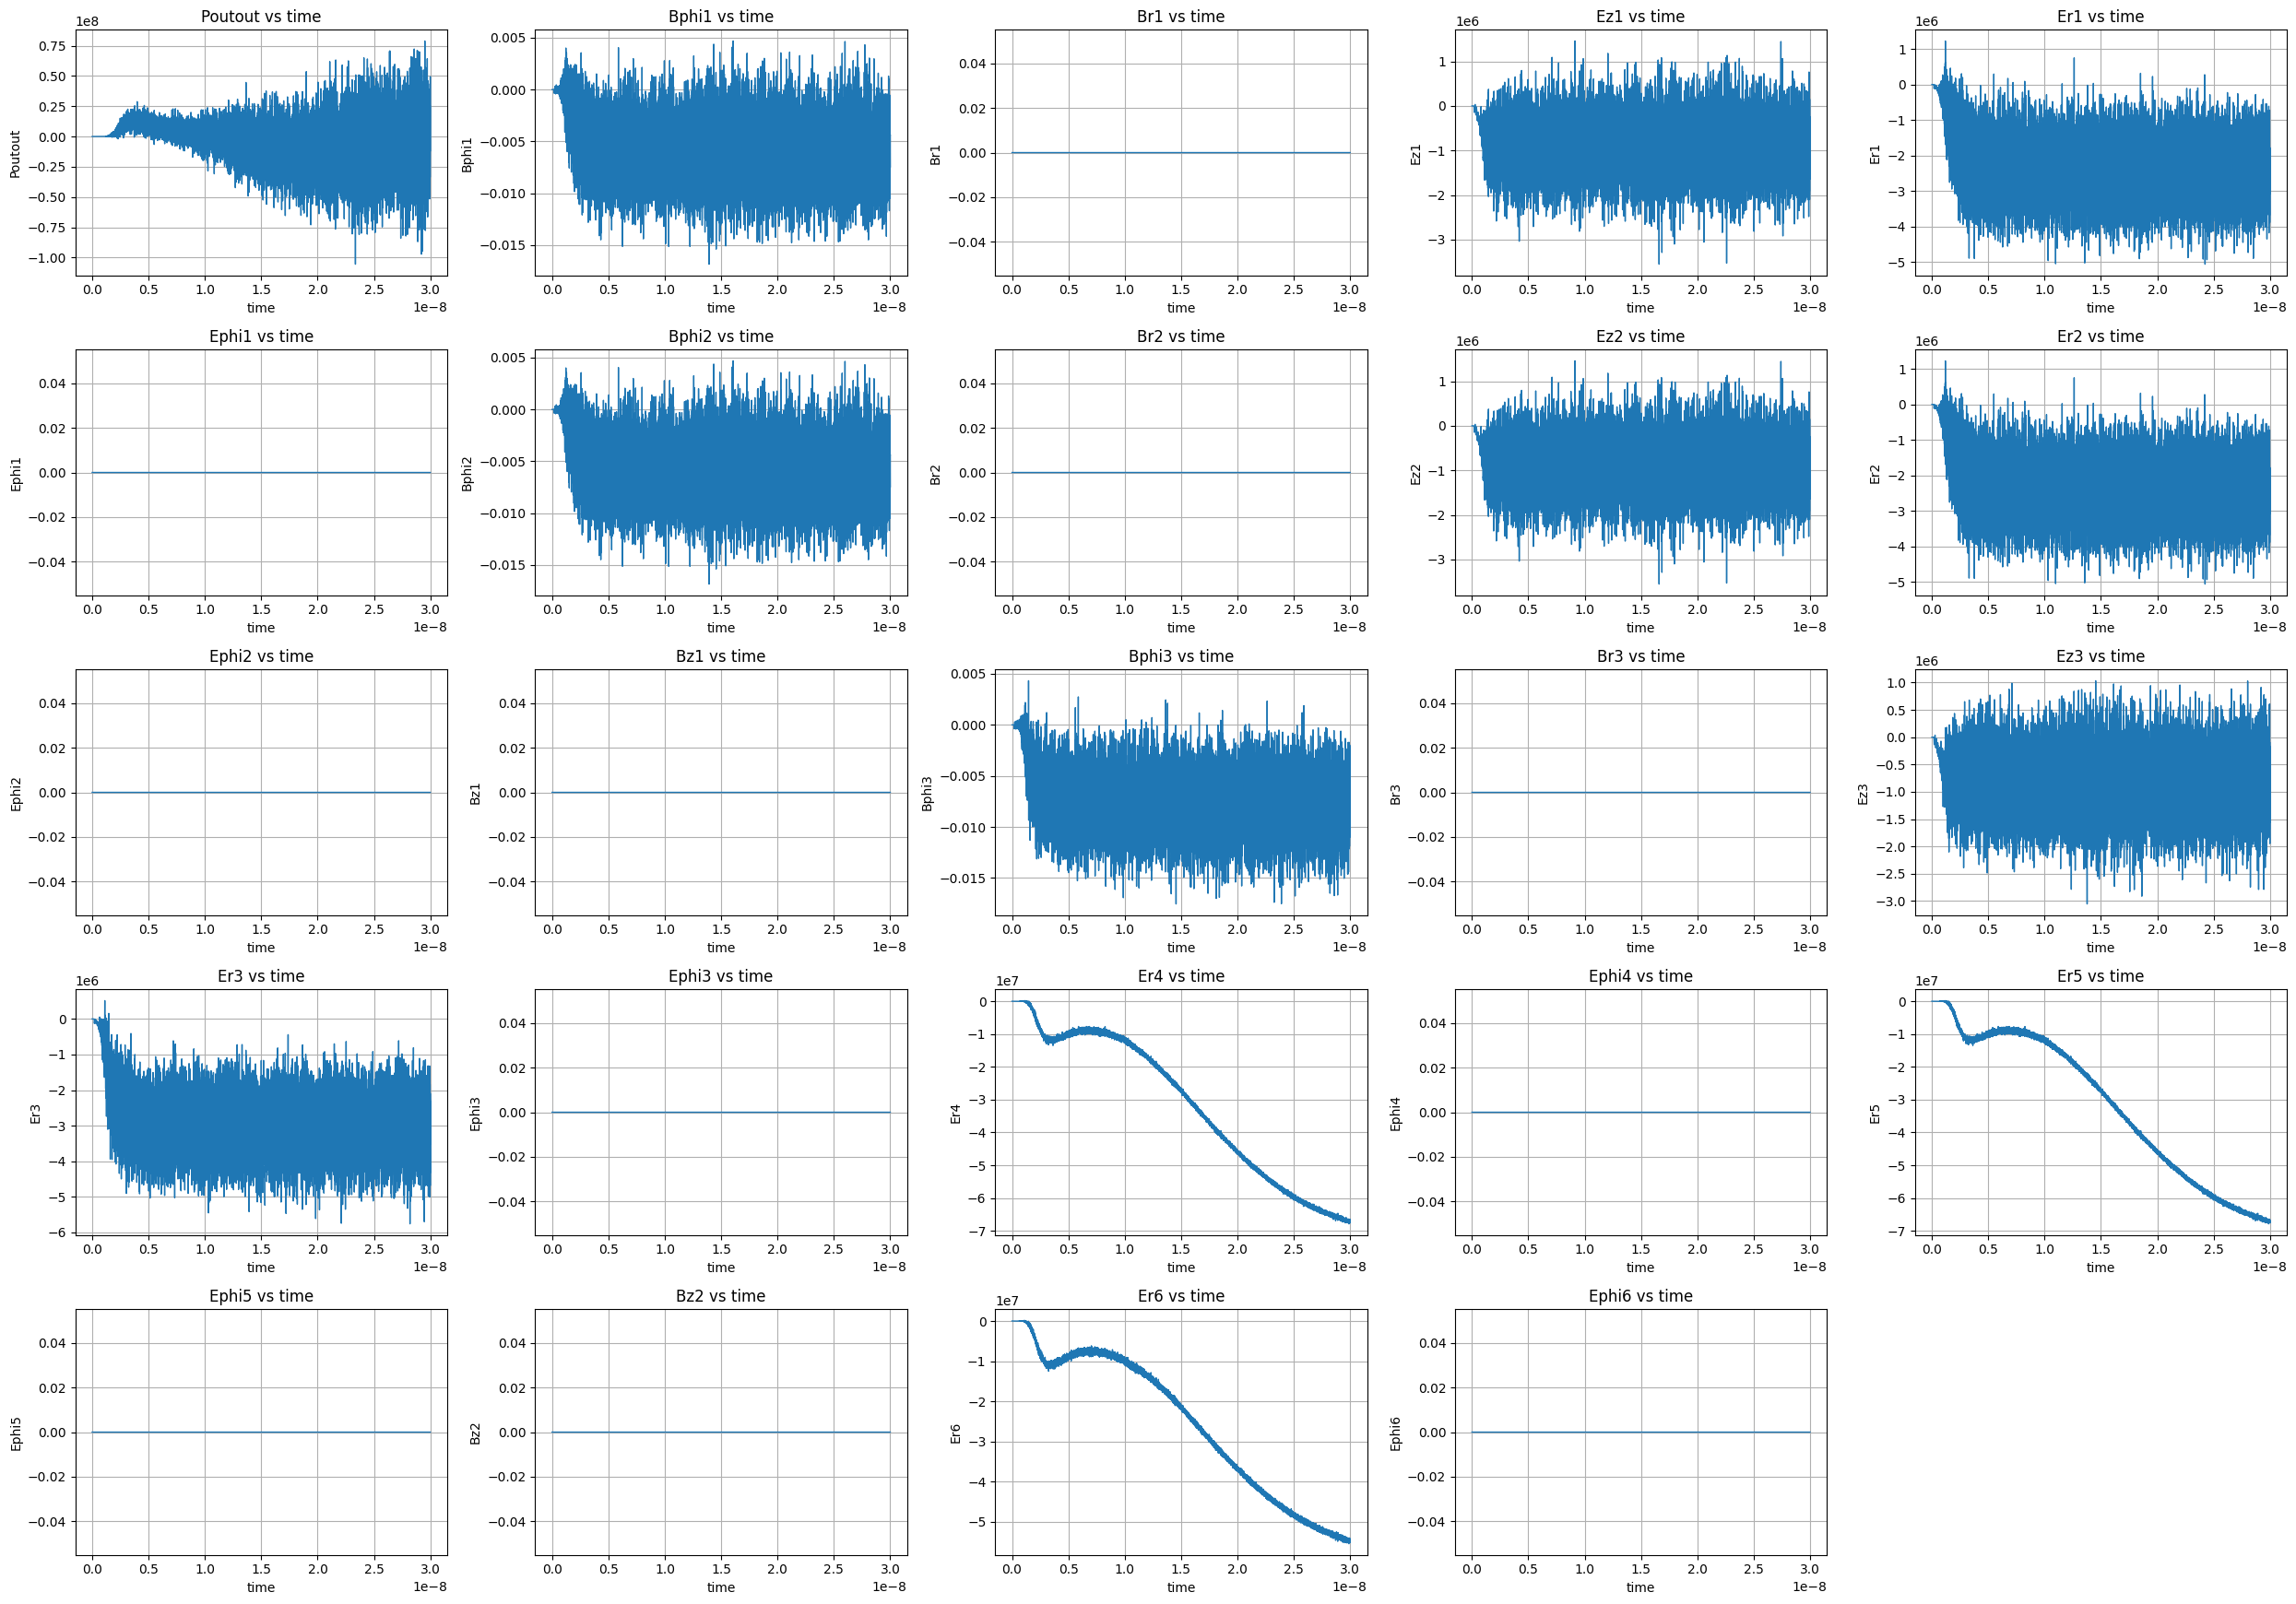

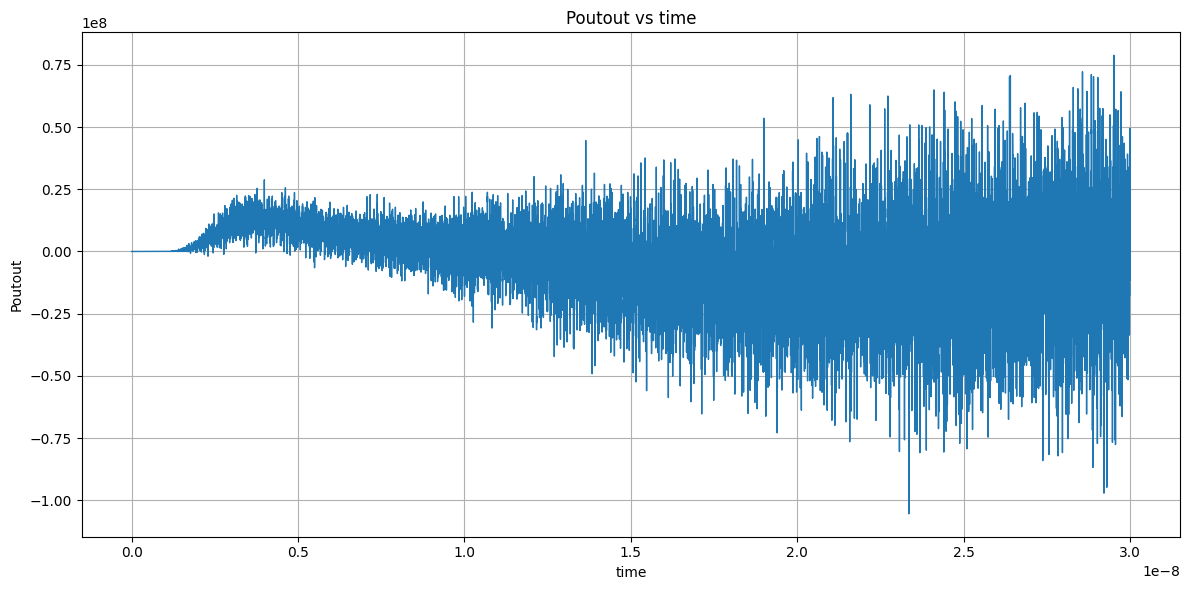

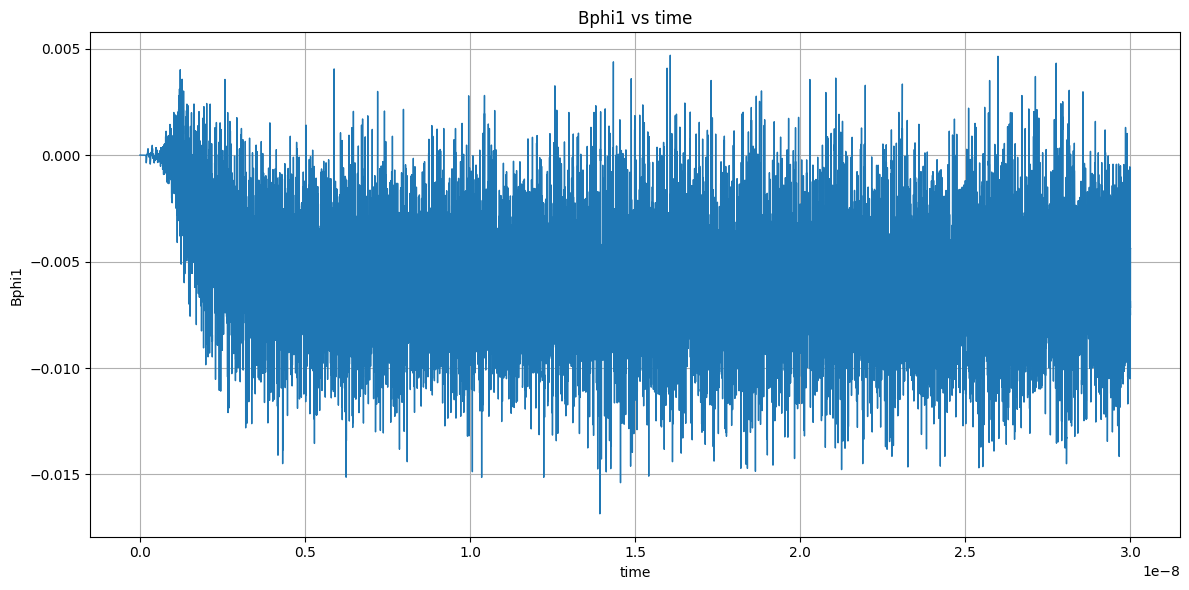

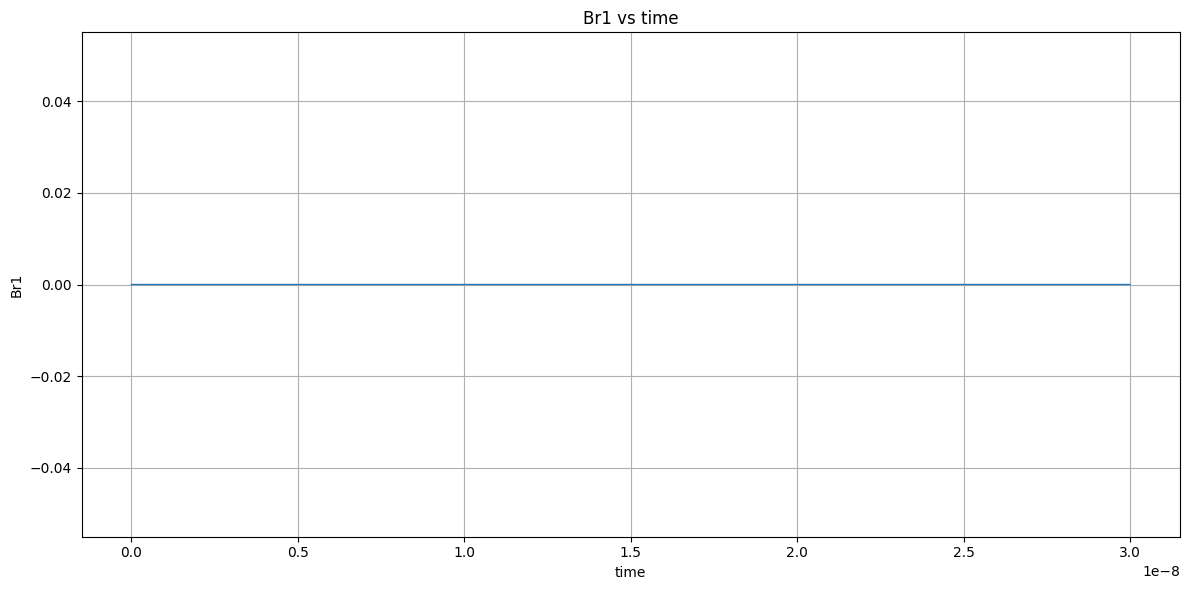

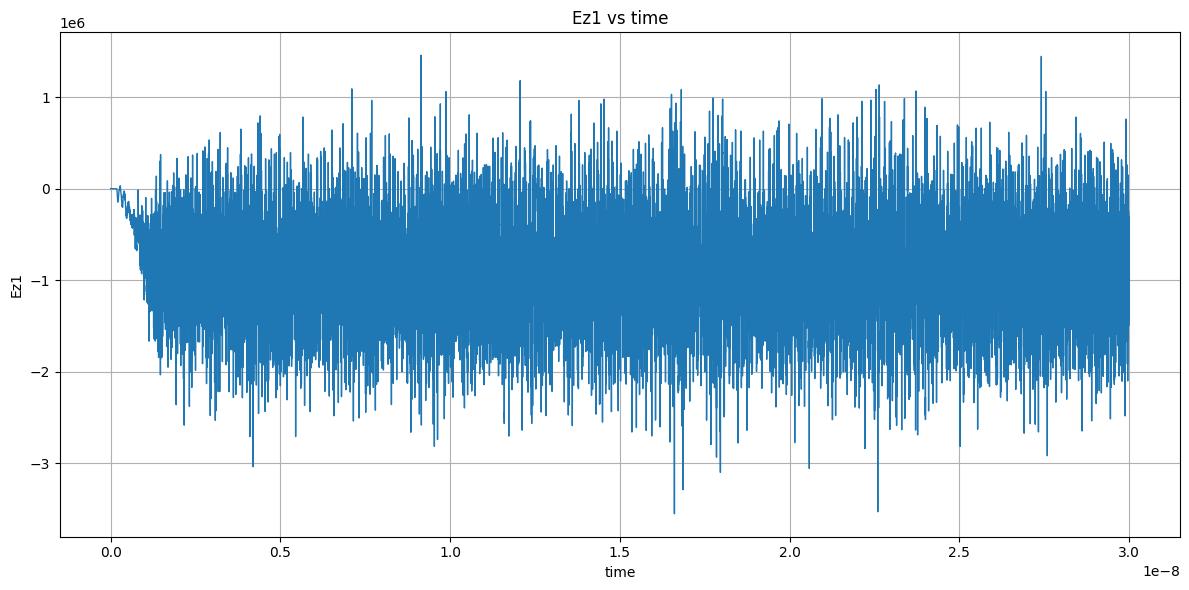

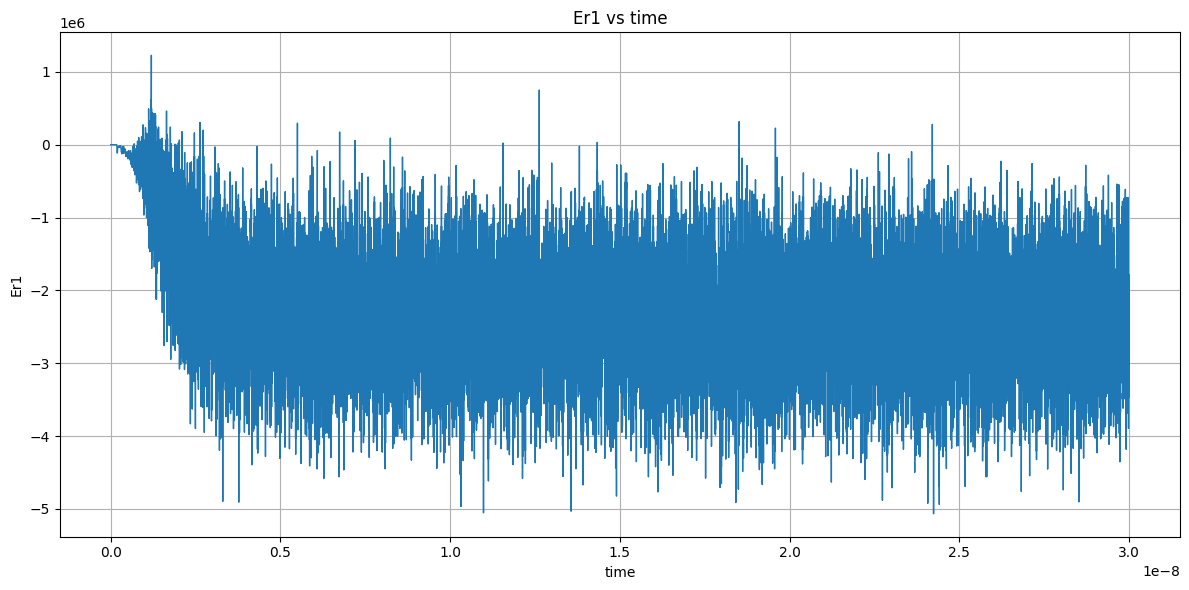

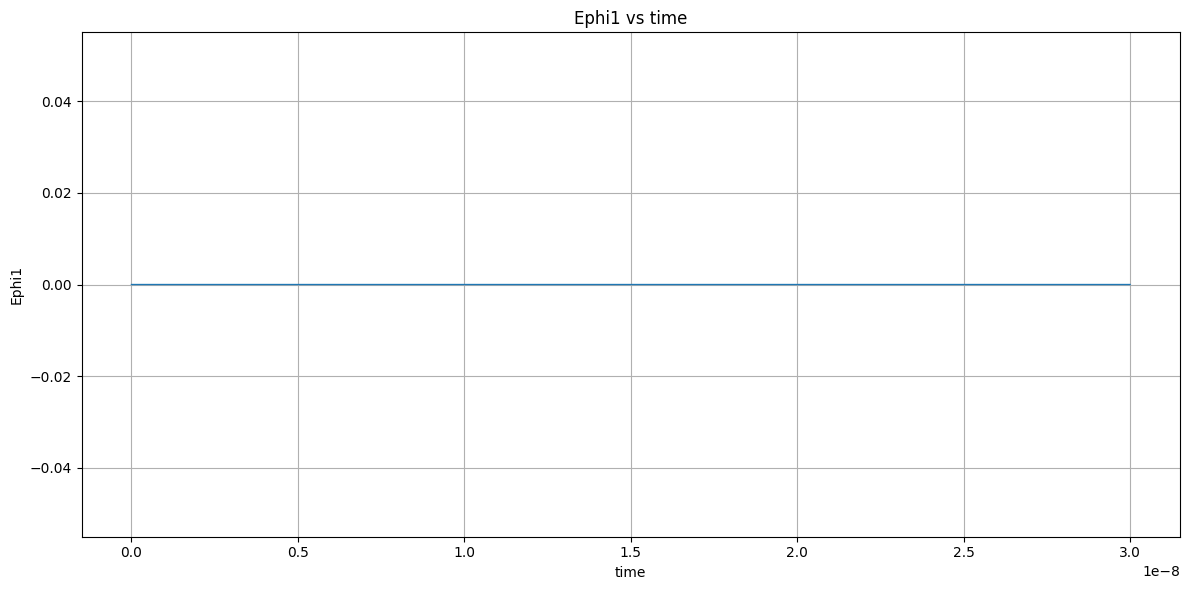

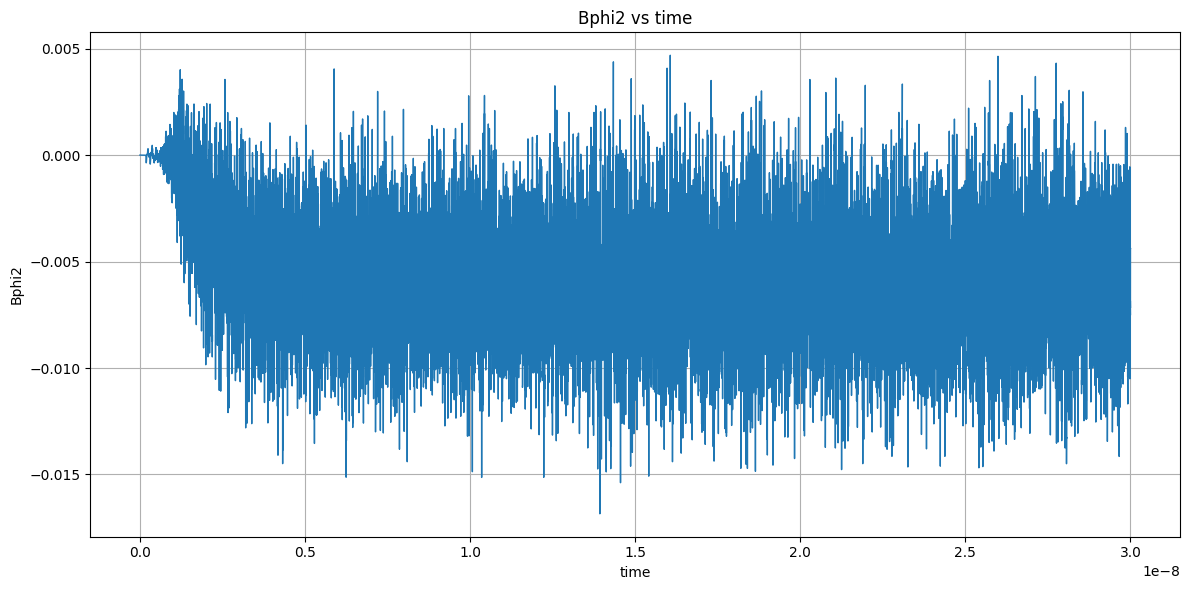

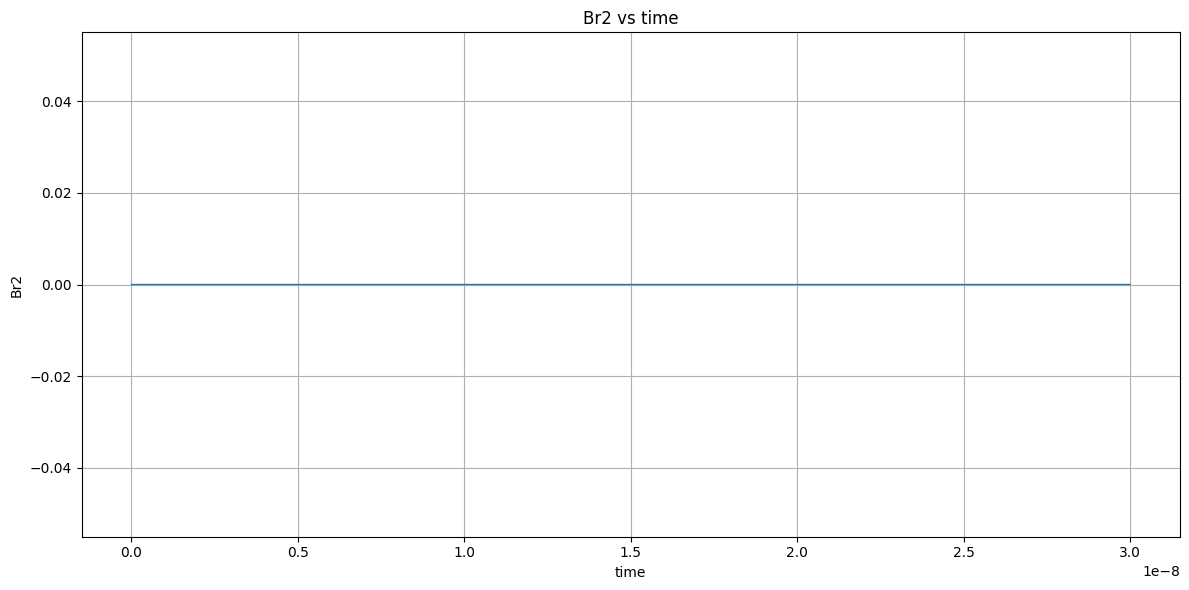

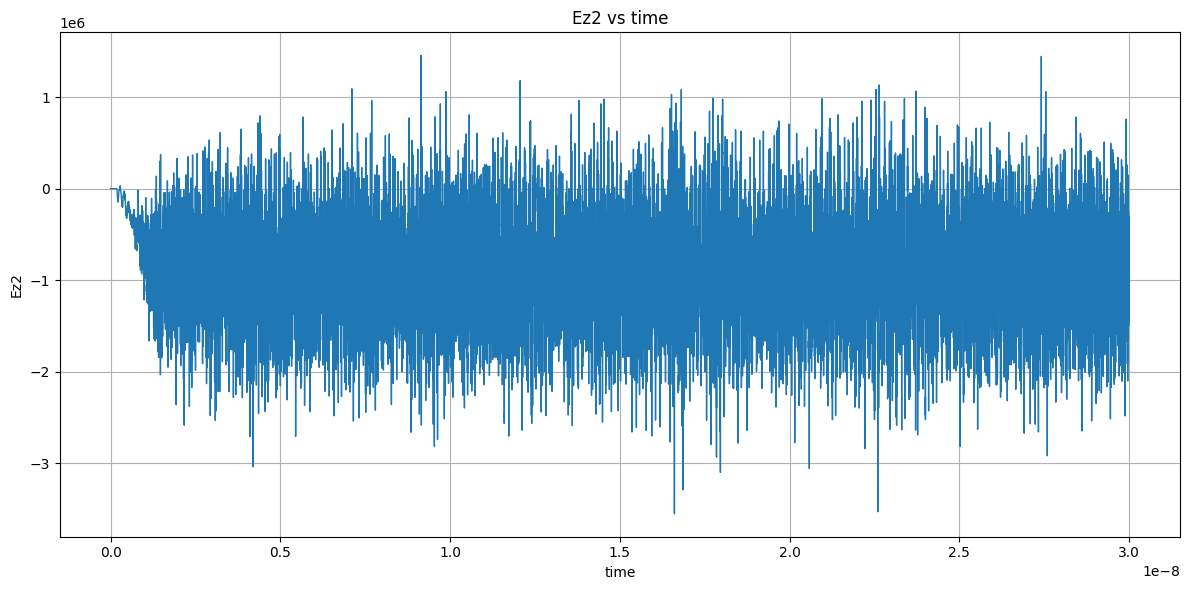

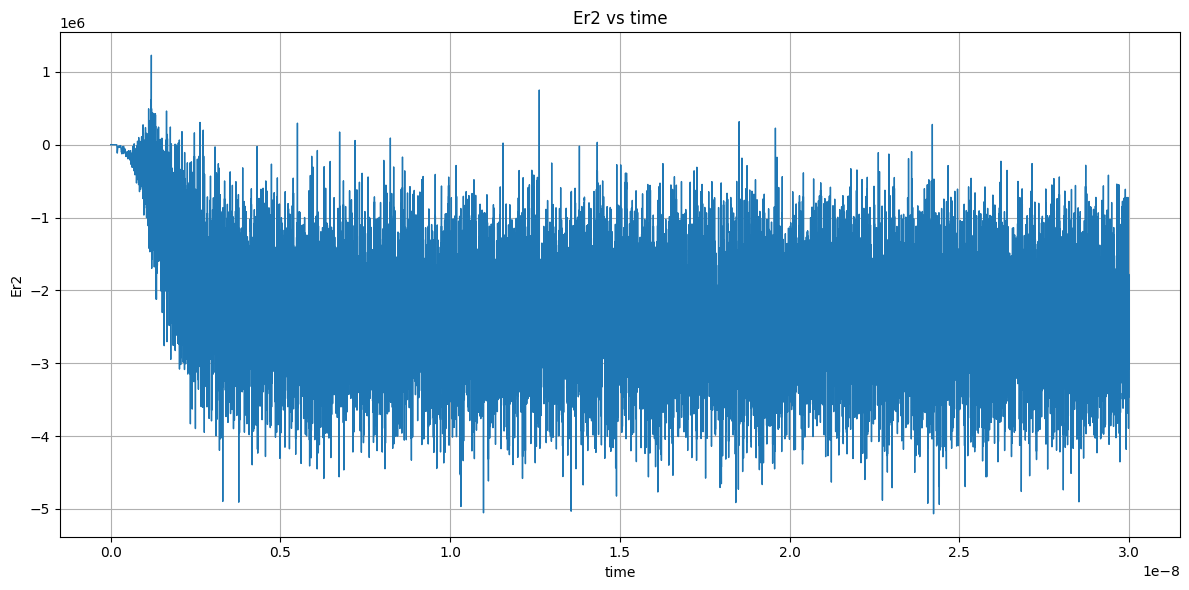

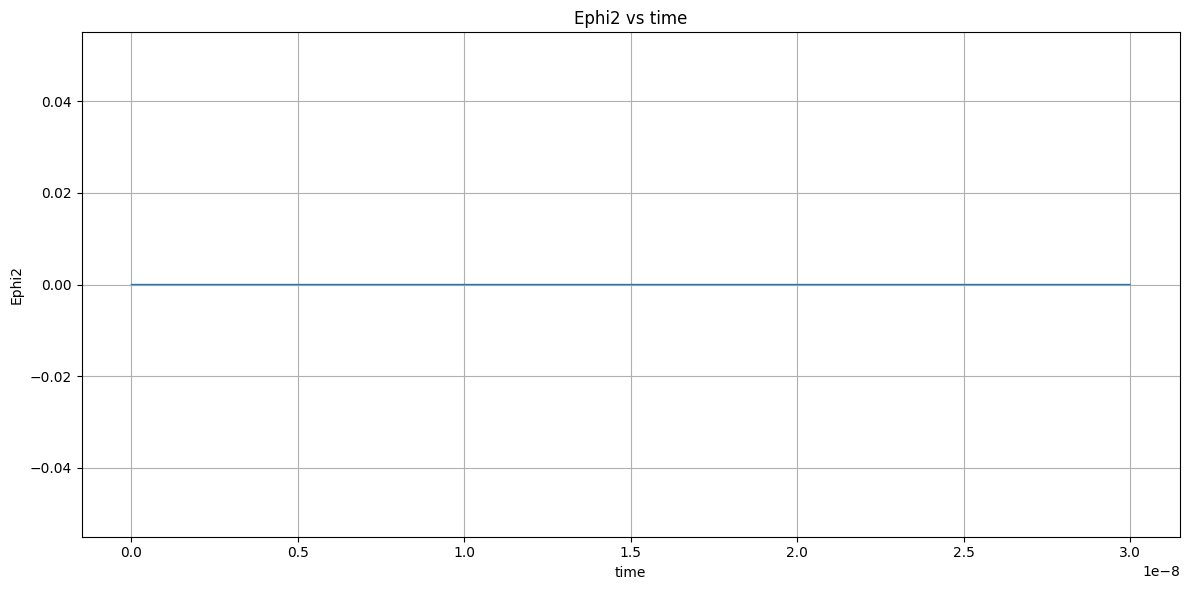

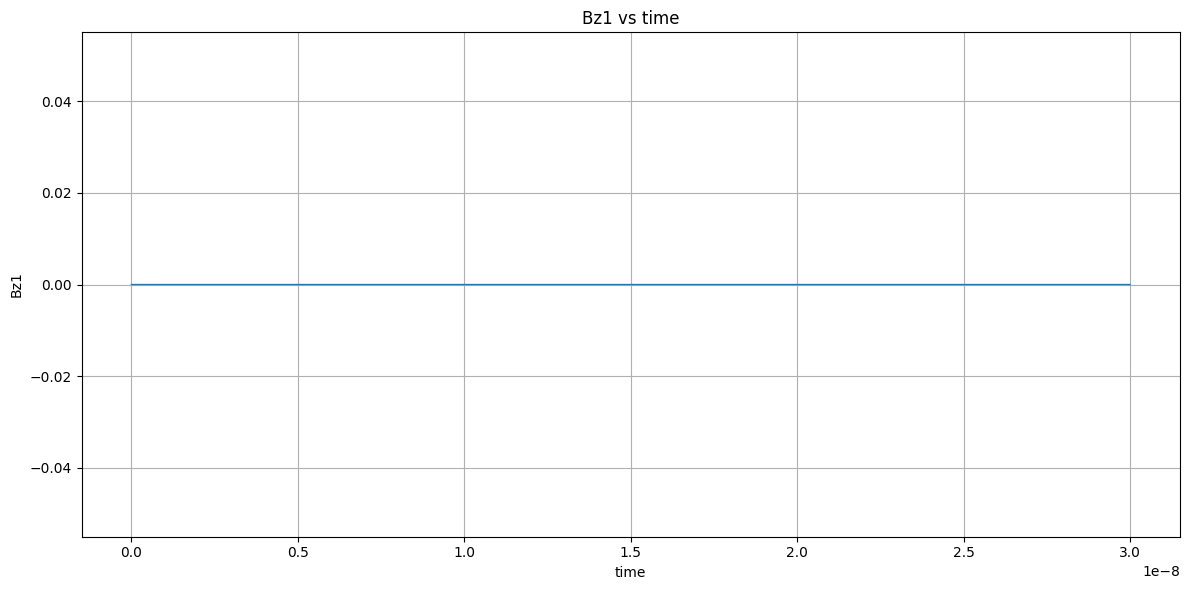

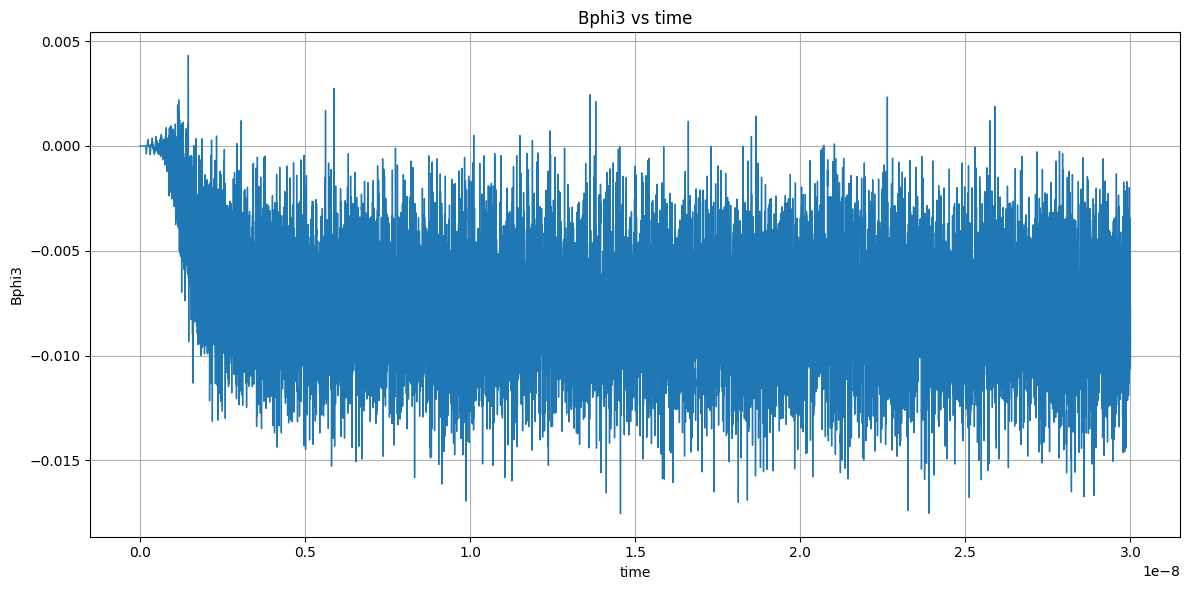

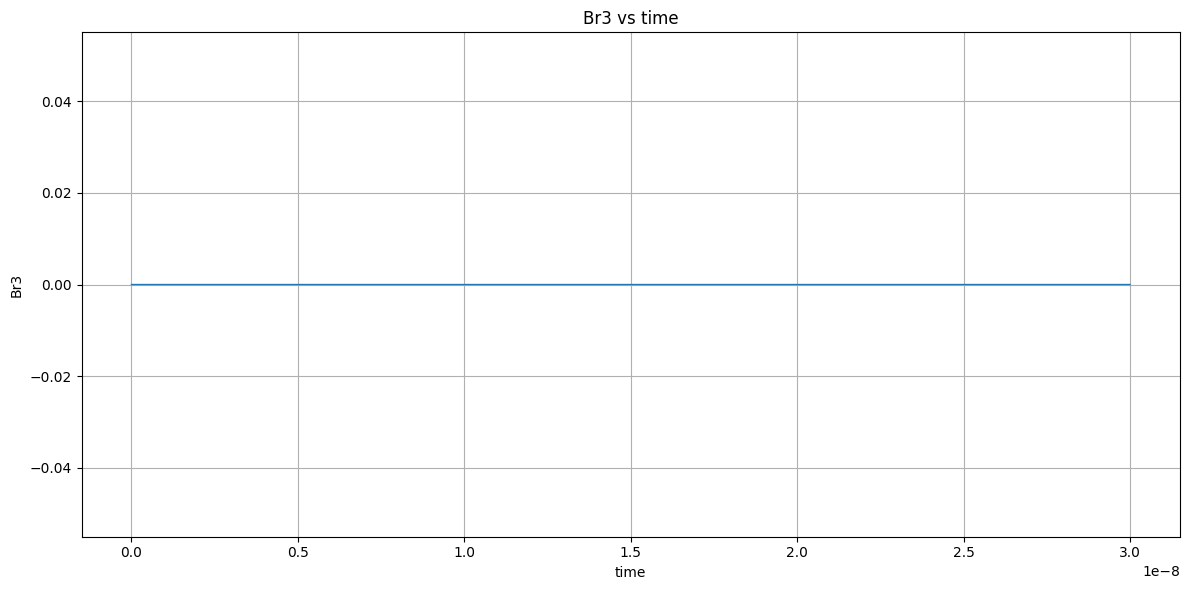

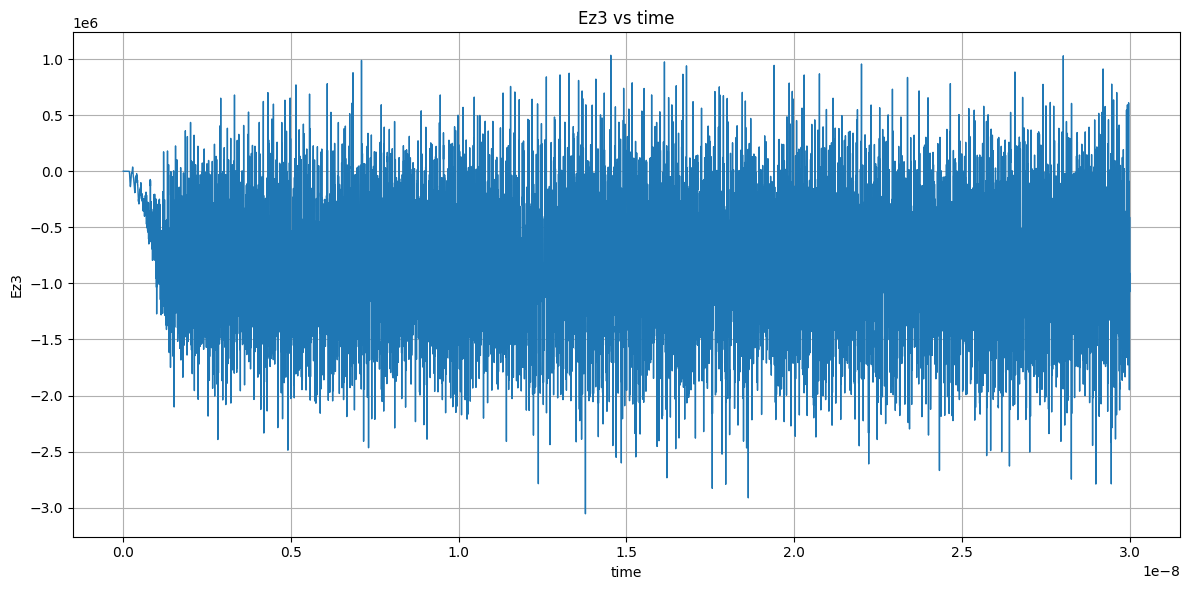

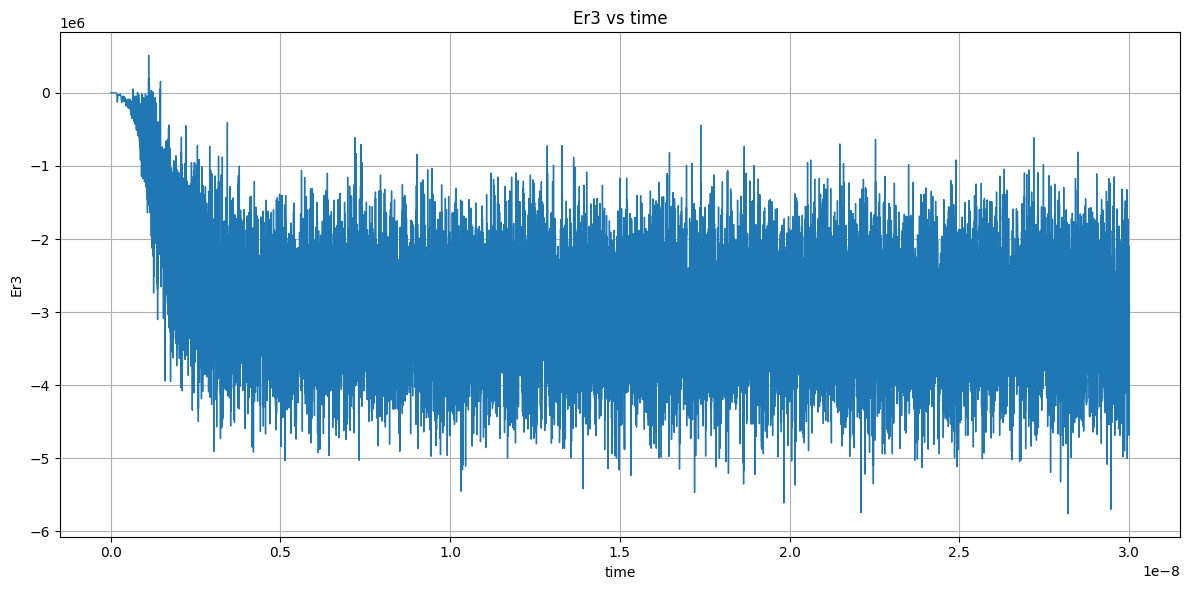

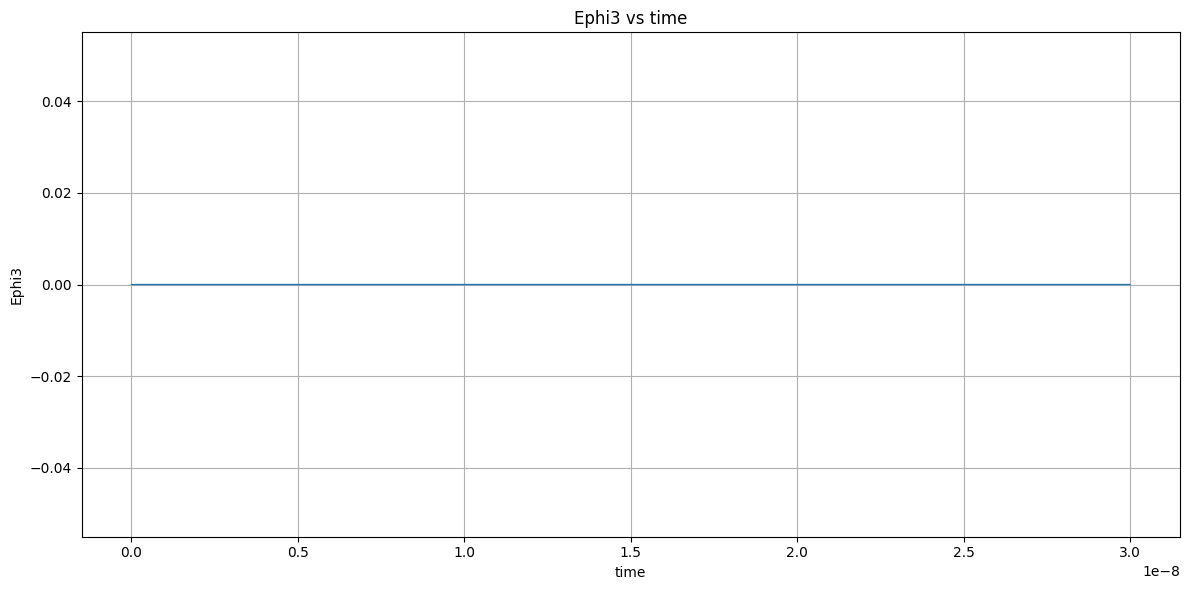

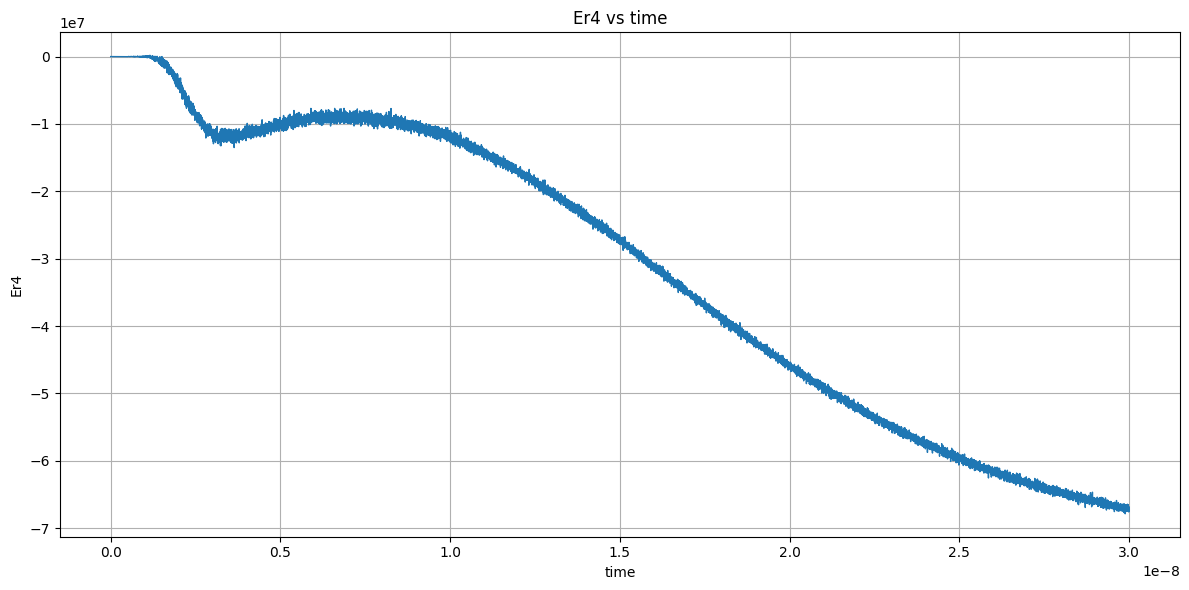

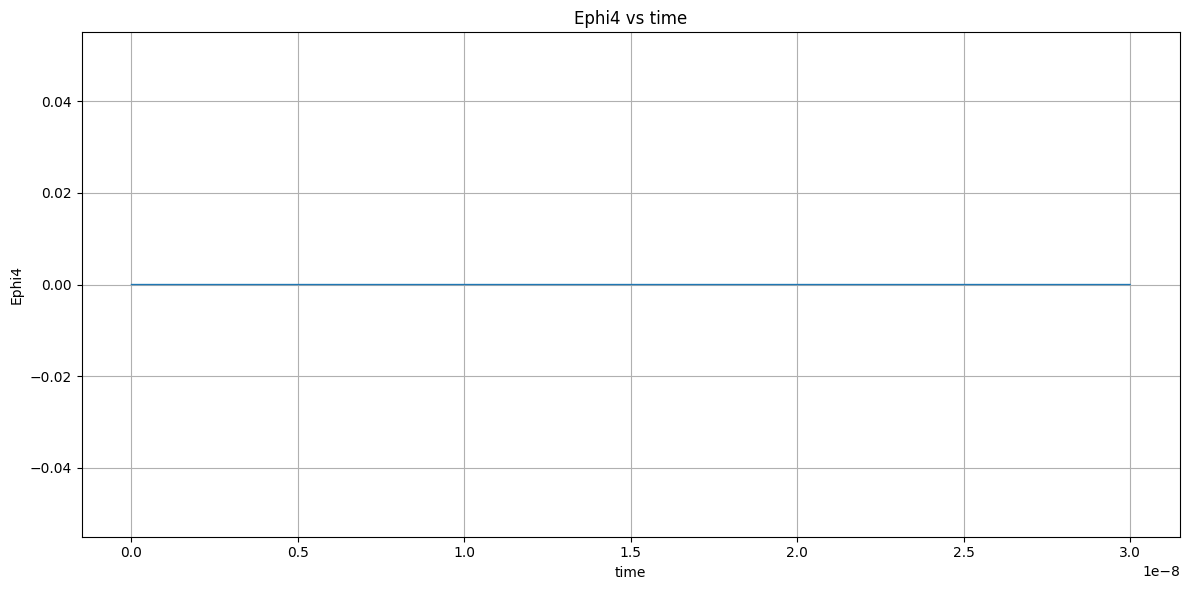

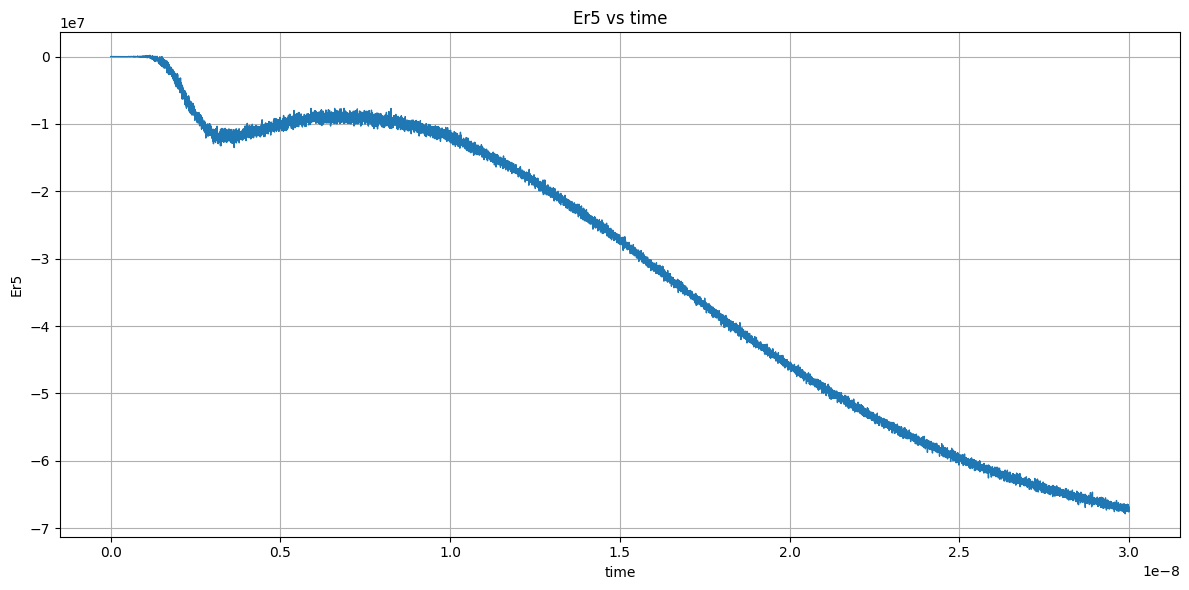

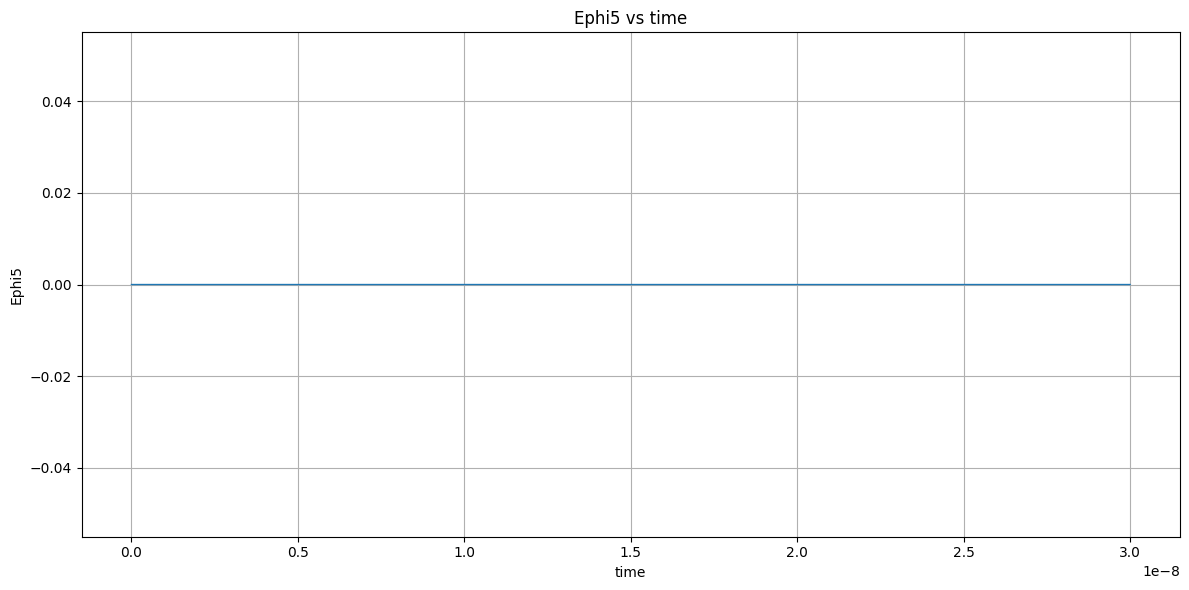

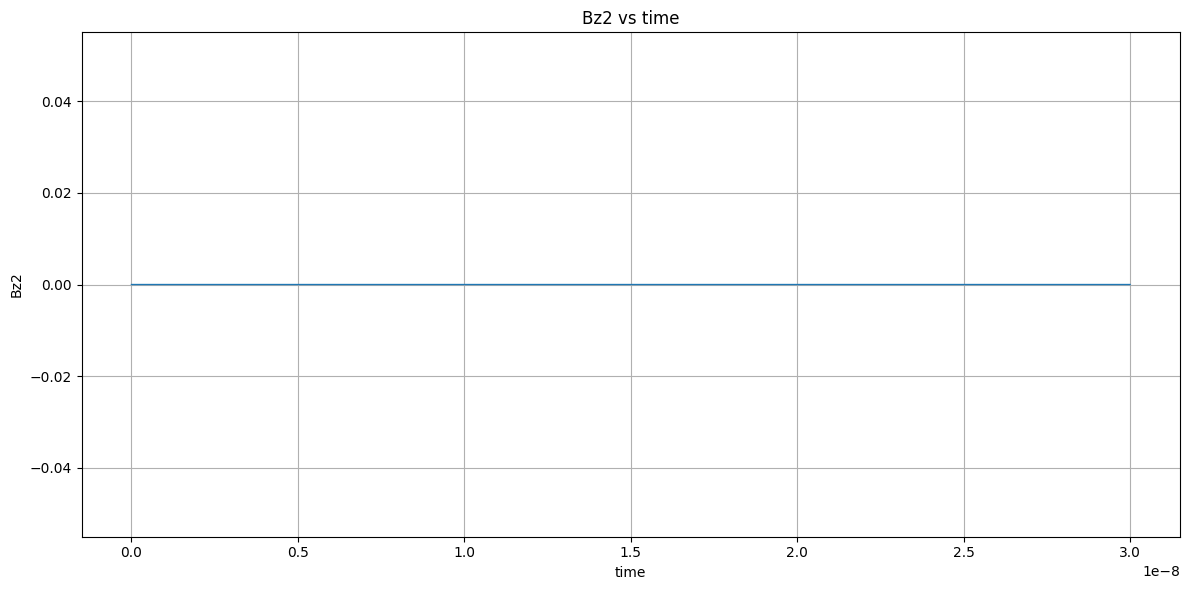

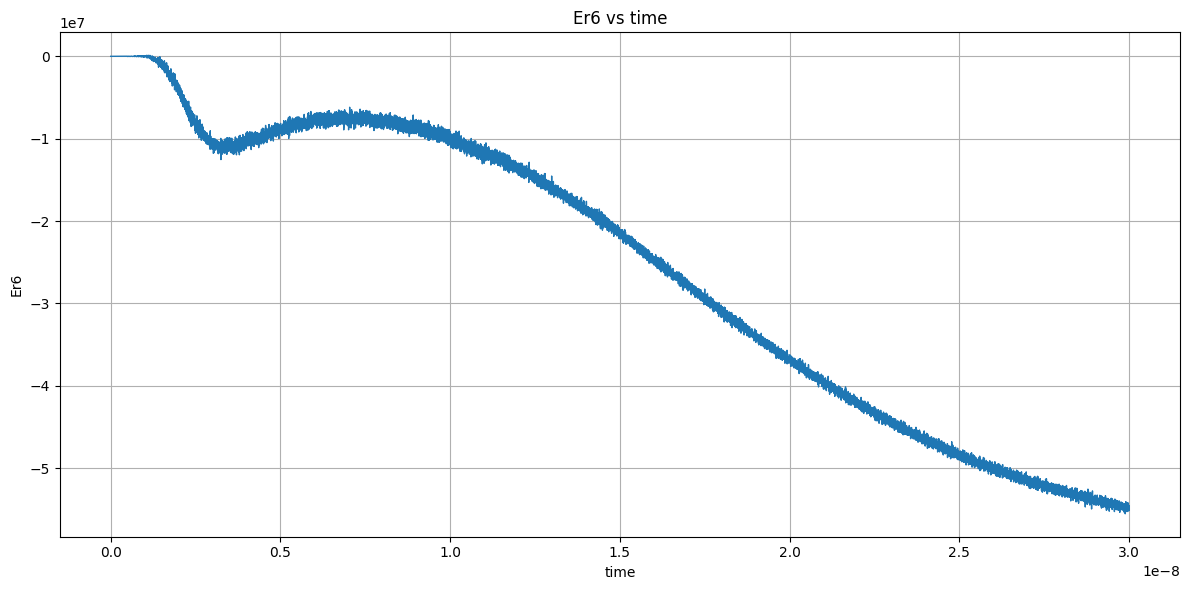

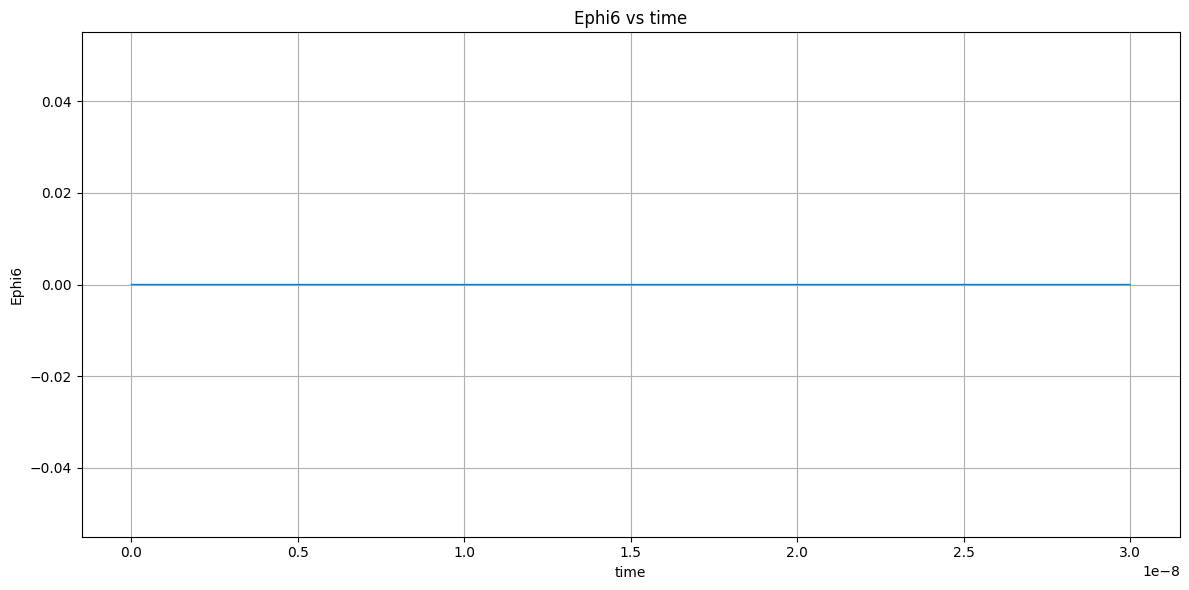

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_multi_columns(txt_path, include=None, layout='separate'):
    """
    txt_path : 文本结果文件路径
    include  : 仅绘制的列名列表（不含 'time'）。例如 ['Poutout','Ez1','Er1']
               默认为 None 表示绘制除 time 以外的全部列
    layout   : 'separate' 每个变量单独一张图；'grid' 自动排版到网格（行列自适应）
    """
    txt_path = Path(txt_path)

    # 1) 读取首行表头并切分为列名
    with open(txt_path, 'r', encoding='utf-8', errors='ignore') as f:
        header_line = f.readline().strip()
    headers = header_line.split()  # 按任意空白分隔

    # 2) 读取数值（跳过首行）
    data = np.loadtxt(txt_path, skiprows=1)
    if data.ndim == 1:   # 仅一行数据时，保证是 2D
        data = data.reshape(1, -1)

    # 3) 找到时间列（若不存在“time”，则默认第0列）
    try:
        time_idx = headers.index('time')
    except ValueError:
        time_idx = 0
        print("警告：未在表头找到 'time'，默认使用第1列作为时间。")

    # 4) 列名与数据列数一致性检查
    n_cols = data.shape[1]
    if len(headers) != n_cols:
        print(f"警告：表头列数({len(headers)})与数据列数({n_cols})不一致，将按最小列数对齐。")
        m = min(len(headers), n_cols)
        headers = headers[:m]
        data = data[:, :m]
        # 同时修正 time_idx（如果超界）
        if time_idx >= m:
            time_idx = 0
            print("警告：time 列索引超出范围，重置为第1列。")

    time = data[:, time_idx]

    # 5) 确定需要绘制的列
    if include is None:
        target_cols = [name for i, name in enumerate(headers) if i != time_idx]
    else:
        # 只保留 include 中且实际存在表头的列
        include_set = set(include)
        target_cols = [name for name in headers if name in include_set and name != headers[time_idx]]

    if not target_cols:
        print("没有可绘制的目标列（检查 include 或表头是否正确）。")
        return

    # 6) 绘图
    line_style = dict(linestyle='-', linewidth=1)

    if layout == 'grid':
        # 网格排版：尽量接近正方形
        import math
        n = len(target_cols)
        n_cols_grid = int(math.ceil(np.sqrt(n)))
        n_rows_grid = int(math.ceil(n / n_cols_grid))
        fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(5*n_cols_grid, 3.5*n_rows_grid), squeeze=False)
        axes = axes.ravel()
        for ax_idx, name in enumerate(target_cols):
            y = data[:, headers.index(name)]
            ax = axes[ax_idx]
            ax.plot(time, y, **line_style)
            ax.set_xlabel('time')
            ax.set_ylabel(name)
            ax.set_title(f'{name} vs time')
            ax.grid(True)
        # 隐藏多余子图
        for k in range(len(target_cols), len(axes)):
            axes[k].axis('off')
        fig.tight_layout()
        plt.show()
    
    # 每个变量单独一张图
    for name in target_cols:
        y = data[:, headers.index(name)]
        plt.figure(figsize=(12, 6))
        plt.plot(time, y, **line_style)
        plt.xlabel('time')
        plt.ylabel(name)
        plt.title(f'{name} vs time')
        plt.grid(True)
        plt.tight_layout()
        plt.show()


# ===== 示例用法 =====
result_file1 = r"D:\AAA_PIC\Parser\MCL_PLYParser\src\data\TM03_60GHz_Double\Simulation\result\FieldsDgn.txt"
result_file2 = r"D:\AAA_PIC\Parser\MCL_PLYParser\src\data\BWO\Simulation\result\FieldsDgn.txt"


# 1) 画全部列（除 time）
plot_multi_columns(result_file2, layout='grid')


# 2) 只画某几列（示例）
# plot_multi_columns(result_file, include=['Poutout','Ez1','Er1'], layout='separate')
